https://github.com/saeyslab/multinichenetr/blob/main/vignettes/paired_analysis_SCC.knit.md

- main goals: inferring differentially expressed and active ligand-receptor pairs between conditions of interest and predicting the putative downstream target genes of these pairs
- other tools predict protein ligand-receptor interactions between pairs of cell clusters/types
- first estimate which ligands are expressed by one cell type and which receptors by another
    - then link expressed ligands to expressed receptors if an interaction between ligand and receptor is documented in database of cognate ligand-receptor pairs
- these tools typically return an extensive list of interactions
    - consequence: hard to decide which interactions are most vital ones in system of interest
    - rna level co-expression of ligand and receptor does not necessarily guarantee that ligand & receptor interact physically
    - might overlook esssential interactions that are weakly expressed or not cell-type specific
- NIcheNet predicts downstream affected target genes of expressed ligand-receptor pairs by combining expression data of interacting cells with a model of ligand-target regulatory potential
    - model calculated through network-based data integration of signaling and gene regulatory networks
    - prioritizes expressed pairs according to how strongly their predicted targets are enriched in receiver cell type (ligand activity)

differences/key aspects of multinichenet
- uses sample-level structure instead of treating all cells as independent
- can account for inter-sample heterogeneity, batch effects, covariates & more complex designs
- uses pseudobulk DE (DE by edgeR)
- uses NicheNet ligand acitivty
    - does not only rank LR pairs by ligand/receptor expression
    - also uses NicheNet ligand-target regulatory potential model: does this ligand plausibly explain the DE target genes observed in the receiver cell type?
- ranks interactions based on:
    - ligand is higher in condition of interest in sender
    - receptor is higher in condition of interest in receiver
    - ligand/receptor are cell-type-specific
    - ligand/receptor are expressed in many samples of that condition
    - ligand activity explains receiver DE genes

=> multinichenet connects lr pairs to downstream transcriptional response

difference to scdiffcom
- scdiffcom defines a cci score per condition based on average ligand/receptor expression and tets whether that score changes between conditions
- multinichenet prioritizes lr-target communication patterns by combining pseudobulk de, expression specificity, sample prevalence, nichenet ligand activity
    - also asks whether the ligand could explain receiver-cell transcriptional changes

In [1]:
suppressPackageStartupMessages({
  library(Seurat)
  library(dplyr)
  library(tidyr)
  library(tibble)
  library(stringr)
  library(purrr)
  library(ggplot2)
  library(forcats)
  library(circlize)
  library(tidyverse)
  library(SingleCellExperiment)
  library(nichenetr)
  library(multinichenetr)
  library(dplyr)
  library(magrittr)
})

set.seed(123)

# "gated_ImmuneAging.rds", "gated_heart_processed.rds", "gated_sepsis_processed.rds", "gated_vaccine_processed.rds", "gated_our_dataset_processed.rds"
#file_name <- "gated_ImmuneAging.rds"
#file_name <- "gated_heart_processed.rds" 
file_name <- "gated_sepsis_processed.rds" 
#file_name <- "gated_vaccine_processed.rds" 
#file_name <- "gated_our_dataset_processed.rds" 

input_file <- "/nfs/home/students/i.kaciran/FoPra_PLAs/data/datasets/gated_sepsis_processed.rds"
out_dir <- "/nfs/home/students/i.kaciran/FoPra_PLAs/results/differential_ccs/v2/scDiffCom_v2"
plot_dir <- file.path(out_dir, "plots")

dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)
dir.create(plot_dir, recursive = TRUE, showWarnings = FALSE)

message("Output directory: ", out_dir)

Warning message:
“replacing previous import ‘e1071::element’ by ‘ggplot2::element’ when loading ‘nichenetr’”
Warning message in checkDepPackageVersion(dep_pkg = "TMB"):
“Package version inconsistency detected.
glmmTMB was built with TMB version 1.9.16
Current TMB version is 1.9.17
Please re-install glmmTMB from source or restore original ‘TMB’ package (see '?reinstalling' for more information)”
Output directory: /nfs/home/students/i.kaciran/FoPra_PLAs/results/differential_ccs/v2/scDiffCom_v2



Load prior knowledge networks from NicheNet
- ligand-receptor network: which ligands can bind which receptors
- ligand-target matrix: which ligands are predicted to regulate which downstream target genes

# 1. Load & prepare data

In [2]:
seurat_obj <- readRDS(input_file)

DefaultAssay(seurat_obj)
ncol(seurat_obj)
nrow(seurat_obj)
colnames(seurat_obj@meta.data)

[1] "RNA"

[1] 285043

[1] 37487

[1] "orig.ident"                             
 [2] "nCount_RNA"                             
 [3] "nFeature_RNA"                           
 [4] "nCount_ADT"                             
 [5] "nFeature_ADT"                           
 [6] "sample"                                 
 [7] "donor_id"                               
 [8] "cell_barcodes"                          
 [9] "scRNA.seq"                              
[10] "TCR"                                    
[11] "BCR"                                    
[12] "CITE.seq"                               
[13] "Bulk.RNA.seq"                           
[14] "Olink.proteomics"                       
[15] "Gender"                                 
[16] "Age"                                    
[17] "Sample.Collection.Date"                 
[18] "Sample.Collection.Site"                 
[19] "Group"                                  
[20] "Sepsis.Infection.Source"                
[21] "Ethnicity"                              
[22] "Chronic.comorbidity.None"               
[23] "Cardiovascular.compromise"              
[24] "COPD"                                   
[25] "Hypertension"                           
[26] "Diabetes"                               
[27] "Respiratory.insufficiency"              
[28] "Renal.insufficiency"                    
[29] "Tuberculosis"                           
[30] "Length.of.ICU.stay.days"                
[31] "Length.of.hospital.stay.days"           
[32] "X14.day.mortality..Deceased.1.Living.0."
[33] "X28.day.mortality..Deceased.1.Living.0."
[34] "X90.day.mortality..Deceased.1.Living.0."
[35] "Gram.positive.bacteria"                 
[36] "Gram.negative.bacteria"                 
[37] "Virus"                                  
[38] "Fungi"                                  
[39] "Microbiology.laboratory..Unknown"       
[40] "SOFA.score"                             
[41] "Shock"                                  
[42] "Organ.failure"                          
[43] "Mechanical.ventilation"                 
[44] "percent.mt"                             
[45] "percent.ribo"                           
[46] "percent.hb"                             
[47] "mt_outlier_all"                         
[48] "is_outlier_RNA"                         
[49] "is_outlier_protein"                     
[50] "is_outlier"                             
[51] "scDblFinder.class"                      
[52] "scDblFinder.score"                      
[53] "RNA_snn_res.0.8"                        
[54] "seurat_clusters"                        
[55] "RNA_snn_res.0.25"                       
[56] "RNA.weight"                             
[57] "ADT.weight"                             
[58] "leiden_0.8_totalVI"                     
[59] "leiden_0.25_totalVI"                    
[60] "celltype_full"                          
[61] "lineage"                                
[62] "pla_status"                             
[63] "celltype"

In [3]:
organism = "human"

In [4]:
options(timeout = 120)

# which ligands can bind which receptors?
lr_network_all = 
readRDS(url(
    "https://zenodo.org/record/10229222/files/lr_network_human_allInfo_30112033.rds"
    )) %>% 
mutate(
    ligand = convert_alias_to_symbols(ligand, organism = organism), 
    receptor = convert_alias_to_symbols(receptor, organism = organism))

lr_network_all = lr_network_all  %>% 
mutate(ligand = make.names(ligand), receptor = make.names(receptor)) 

lr_network = lr_network_all %>% 
distinct(ligand, receptor)

# which target genes are predicted to be regulated by each ligand?
ligand_target_matrix = readRDS(url(
"https://zenodo.org/record/7074291/files/ligand_target_matrix_nsga2r_final.rds"
))


# columns = ligands, rows = target genes
colnames(ligand_target_matrix) = colnames(ligand_target_matrix) %>% 
convert_alias_to_symbols(organism = organism) %>% make.names()
rownames(ligand_target_matrix) = rownames(ligand_target_matrix) %>% 
convert_alias_to_symbols(organism = organism) %>% make.names()

# lr_network ligands == ligand_target_matrix ligands
lr_network = lr_network %>% filter(ligand %in% colnames(ligand_target_matrix))
ligand_target_matrix = ligand_target_matrix[, lr_network$ligand %>% unique()]

[1] "following are the official gene symbols of input aliases: "
  symbol alias
1  YARS1  YARS
[1] "all input symbols were official symbols"
[1] "all input symbols were official symbols"
[1] "all input symbols were official symbols"


Important: It is required that each sample-id is uniquely assigned to only one condition/group of interest. See the vignettes about paired and multifactorial analysis to see how to define your analysis input when you have multiple samples (and conditions) per patient.

In [5]:
sample_condition_check <- seurat_obj@meta.data %>%
  dplyr::distinct(sample, pla_status) %>%
  dplyr::count(sample, name = "n_conditions") %>%
  dplyr::filter(n_conditions > 1)

sample_condition_check

sample,n_conditions
<chr>,<int>
GSM8571042_Abd-S111,2
GSM8571043_Abd-S23,2
GSM8571044_Abd-S42,2
GSM8571045_Abd-S45,2
GSM8571046_Abd-S49,2
GSM8571047_Abd-S51,2
GSM8571048_Abd-S55,2
GSM8571049_Abd-S66,2
GSM8571050_Abd-S67,2


In [6]:
length(unique(seurat_obj$sample))

[1] 40

In [7]:
seurat_obj@meta.data %>%
  dplyr::distinct(sample, pla_status) %>%
  dplyr::count(pla_status)

pla_status,n
<chr>,<int>
PLA,40
platelet-free,40


Our samples occur in multiple conditions -> we need paired analysis setup.

sample_id = sample_condition: unique experimental unit used for pseudobulk

group_id = pla_status: condition to compare: PLA vs platelet-free

covariates = sample: pairing variable / patient ID, controls for the fact that PLA and platelet-free come from the same sample

batches = NA: if we do not have a separate technical batch to correct normalized expression values for

In [8]:
seurat_obj$sample_condition <- paste(
  seurat_obj$sample,
  seurat_obj$pla_status,
  sep = "_"
)

In [9]:
sample_id = "sample_condition"
group_id = "pla_status"
celltype_id = "lineage"

covariates = "sample"
batches = NA

In [10]:
contrasts_oi = c("'PLA', 'platelet-free'")

For downstream visualizations and linking contrasts to their main condition, we also need to run the following: This is necessary because we will also calculate cell-type+condition specificity of ligands and receptors.

In [11]:
contrast_tbl = tibble(contrast =
                        c("PLA, platelet-free"),
                      group = c("PLA, platelet-free"))

In [12]:
contrast_tbl

contrast,group
<chr>,<chr>
"PLA, platelet-free","PLA, platelet-free"


MultiNicheNet reads in a SingleCellExperiment object. We can convert a Seurat object easily to a SingleCellExperiment object.

In [13]:
sce = Seurat::as.SingleCellExperiment(seurat_obj, assay="RNA")
sce = alias_to_symbol_SCE(sce, "human") %>% makenames_SCE()

Warning message:
“`PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


[1] "there are provided symbols that are not in the alias annotation table: "
    [1] "ENSG00000260179"  "ENSG00000234396"  "ENSG00000228037" 
    [4] "ENSG00000284616"  "ENSG00000238260"  "ENSG00000260972" 
    [7] "ENSG00000270035"  "ENSG00000284646"  "ENSG00000284739" 
   [10] "ENSG00000272235"  "ENSG00000284694"  "ENSG00000287356" 
   [13] "ENSG00000224387"  "ENSG00000285629"  "ENSG00000272161" 
   [16] "ENSG00000287727"  "ENSG00000223989"  "ENSG00000228423" 
   [19] "ENSG00000286448"  "ENSG00000237365"  "ENSG00000284703" 
   [22] "ENSG00000241326"  "ENSG00000285701"  "ENSG00000233645" 
   [25] "ENSG00000284708"  "ENSG00000235146"  "ENSG00000236601" 
   [28] "ENSG00000228150"  "ENSG00000229393"  "ENSG00000269978" 
   [31] "ENSG00000287586"  "ENSG00000227169"  "ENSG00000272482" 
   [34] "ENSG00000284747"  "ENSG00000238290"  "ENSG00000225387" 
   [37] "ENSG00000288398"  "ENSG00000224621"  "ENSG00000285833" 
   [40] "ENSG00000284692"  "ENSG00000284745"  "ENSG00000225952" 
   [43] "ENS

In [14]:
#sce <- sce[, !is.na(SummarizedExperiment::colData(sce)[, celltype_id])]

#sce <- sce[, !SummarizedExperiment::colData(sce)[, celltype_id] %in% c("NA", "NA.", "", "nan", "NaN")]

In [15]:
SummarizedExperiment::colData(sce)[, sample_id] <- 
  SummarizedExperiment::colData(sce)[, sample_id] %>%
  as.character() %>%
  make.names()

SummarizedExperiment::colData(sce)[, sample_id] <- 
  factor(SummarizedExperiment::colData(sce)[, sample_id])

SummarizedExperiment::colData(sce)[, group_id] <-
  SummarizedExperiment::colData(sce)[, group_id] %>%
  as.character() %>%
  make.names()

SummarizedExperiment::colData(sce)[, group_id] <-
  factor(SummarizedExperiment::colData(sce)[, group_id])


SummarizedExperiment::colData(sce)[, celltype_id] <- 
  SummarizedExperiment::colData(sce)[, celltype_id] %>%
  as.character() %>%
  make.names()

SummarizedExperiment::colData(sce)[, celltype_id] <- 
  factor(SummarizedExperiment::colData(sce)[, celltype_id])

Consider all cell types in data:

In [16]:
senders_oi = SummarizedExperiment::colData(sce)[,"lineage"] %>% unique()
receivers_oi = SummarizedExperiment::colData(sce)[,"lineage"] %>% unique()
sce = sce[, SummarizedExperiment::colData(sce)[,"lineage"] %in% 
            c(senders_oi, receivers_oi)
          ]

# 2. Running the MultiNicheNet core analysis

Now we will run the core of a MultiNicheNet analysis. This analysis consists of the following steps:

1. Cell-type filtering: determine which cell types are sufficiently present
2. Gene filtering: determine which genes are sufficiently expressed in each present cell type
3. Pseudobulk expression calculation: determine and normalize per-sample pseudobulk expression levels for each expressed gene in each present cell type
4. Differential expression (DE) analysis: determine which genes are differentially expressed
5. Ligand activity prediction: use the DE analysis output to predict the activity of ligands in receiver cell types and infer their potential target genes
6. Prioritization: rank cell-cell communication patterns through multi-criteria prioritization

Following these steps, one can optionally

7. Calculate the across-samples expression correlation between ligand-receptor pairs and target genes
8. Prioritize communication patterns involving condition-specific cell types through an alternative prioritization scheme

## Cell-type filtering

In [17]:
min_cells = 10

abundance_info = get_abundance_info(
  sce = sce, 
  sample_id = sample_id, group_id = group_id, celltype_id = celltype_id, 
  min_cells = min_cells, 
  senders_oi = senders_oi, receivers_oi = receivers_oi, 
  batches = batches
  )


Warning message:
“The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the multinichenetr package.
  Please report the issue at
  <https://github.com/browaeysrobin/multinichenetr/issues>.”


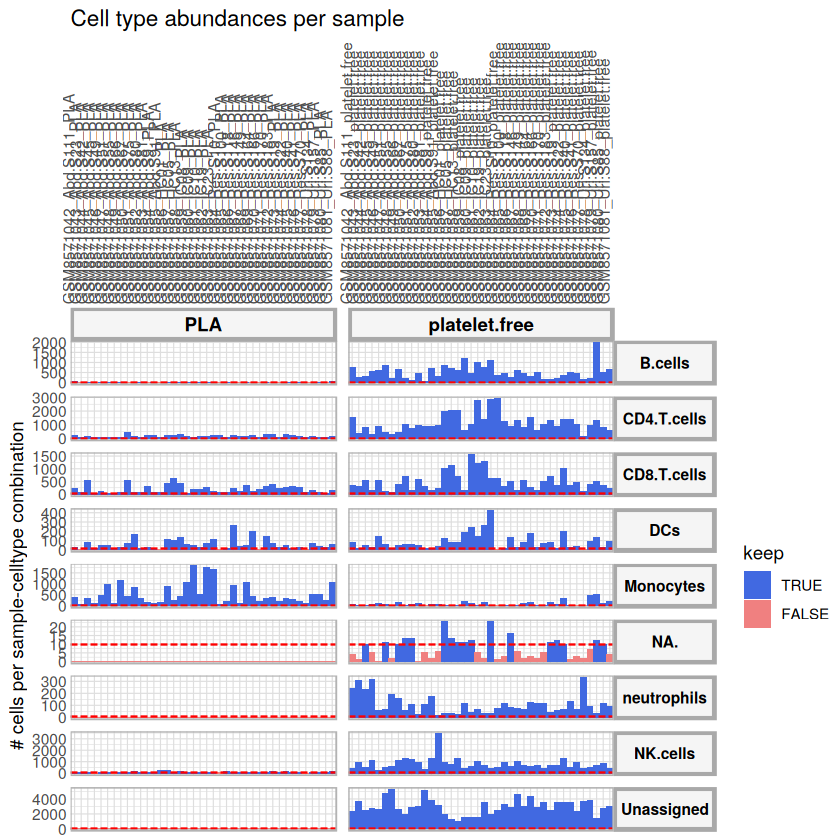

In [18]:
abundance_info$abund_plot_sample

### Which cell types are condition-specific, which cell-types are absent?

In [19]:
sample_group_celltype_df = abundance_info$abundance_data %>% 
  filter(n > min_cells) %>% 
  ungroup() %>% 
  distinct(sample_id, group_id) %>% 
  cross_join(
    abundance_info$abundance_data %>% 
      ungroup() %>% 
      distinct(celltype_id)
    ) %>% 
  arrange(sample_id)
# every sample-condition × every cell type

abundance_df = sample_group_celltype_df %>% left_join(
  abundance_info$abundance_data %>% ungroup()
  )
# joins the actual cell counts back onto the complete table

# missing values: n = 0, keep = F
abundance_df$n[is.na(abundance_df$n)] = 0
abundance_df$keep[is.na(abundance_df$keep)] = FALSE

# count how many samples contain each cell type per condition
abundance_df_summarized = abundance_df %>% 
  mutate(keep = as.logical(keep)) %>% 
  group_by(group_id, celltype_id) %>% 
  summarise(samples_present = sum((keep)))

celltypes_absent_one_condition = abundance_df_summarized %>% 
  filter(samples_present == 0) %>% pull(celltype_id) %>% unique() 
# find truly condition-specific cell types by searching for cell types 
# truely absent in at least one condition

celltypes_present_one_condition = abundance_df_summarized %>% 
  filter(samples_present >= 2) %>% pull(celltype_id) %>% unique() 
# require presence in at least 2 samples of one group so 
# it is really present in at least one condition

# absent in one condition, present in at least 2 samples in another condition
condition_specific_celltypes = intersect(
  celltypes_absent_one_condition, 
  celltypes_present_one_condition)

total_nr_conditions = SummarizedExperiment::colData(sce)[,group_id] %>% 
  unique() %>% length() 

# absent everywhere
absent_celltypes = abundance_df_summarized %>% 
  filter(samples_present < 2) %>% 
  group_by(celltype_id) %>% 
  dplyr::count() %>% 
  filter(n == total_nr_conditions) %>% 
  pull(celltype_id)
  
print("condition-specific celltypes:")
print(condition_specific_celltypes)
  
print("absent celltypes:")
print(absent_celltypes)


Joining with `by = join_by(sample_id, group_id, celltype_id)`
`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by group_id and celltype_id.
ℹ Output is grouped by group_id.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(group_id, celltype_id))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


[1] "condition-specific celltypes:"
[1] "NA."         "neutrophils" "Unassigned" 
[1] "absent celltypes:"
factor()
9 Levels: B.cells CD4.T.cells CD8.T.cells DCs Monocytes NA. ... Unassigned


In [20]:
sample_group_celltype_df

sample_id,group_id,celltype_id
<fct>,<fct>,<fct>
GSM8571042_Abd.S111_PLA,PLA,B.cells
GSM8571042_Abd.S111_PLA,PLA,CD4.T.cells
GSM8571042_Abd.S111_PLA,PLA,CD8.T.cells
GSM8571042_Abd.S111_PLA,PLA,DCs
GSM8571042_Abd.S111_PLA,PLA,Monocytes
GSM8571042_Abd.S111_PLA,PLA,NK.cells
GSM8571042_Abd.S111_PLA,PLA,NA.
GSM8571042_Abd.S111_PLA,PLA,neutrophils
GSM8571042_Abd.S111_PLA,PLA,Unassigned


In [21]:
abundance_df

sample_id,group_id,celltype_id,n,keep
<fct>,<fct>,<fct>,<dbl>,<fct>
GSM8571042_Abd.S111_PLA,PLA,B.cells,28,TRUE
GSM8571042_Abd.S111_PLA,PLA,CD4.T.cells,187,TRUE
GSM8571042_Abd.S111_PLA,PLA,CD8.T.cells,212,TRUE
GSM8571042_Abd.S111_PLA,PLA,DCs,24,TRUE
GSM8571042_Abd.S111_PLA,PLA,Monocytes,364,TRUE
GSM8571042_Abd.S111_PLA,PLA,NK.cells,25,TRUE
GSM8571042_Abd.S111_PLA,PLA,NA.,0,FALSE
GSM8571042_Abd.S111_PLA,PLA,neutrophils,0,FALSE
GSM8571042_Abd.S111_PLA,PLA,Unassigned,0,FALSE


In [22]:
abundance_df_summarized

group_id,celltype_id,samples_present
<fct>,<fct>,<int>
PLA,B.cells,24
PLA,CD4.T.cells,40
PLA,CD8.T.cells,40
PLA,DCs,35
PLA,Monocytes,40
PLA,NA.,0
PLA,neutrophils,0
PLA,NK.cells,36
PLA,Unassigned,0


In [23]:
celltypes_absent_one_condition

[1] NA.         neutrophils Unassigned 
9 Levels: B.cells CD4.T.cells CD8.T.cells DCs Monocytes NA. ... Unassigned

In [24]:
celltypes_present_one_condition

[1] B.cells     CD4.T.cells CD8.T.cells DCs         Monocytes   NK.cells   
[7] NA.         neutrophils Unassigned 
9 Levels: B.cells CD4.T.cells CD8.T.cells DCs Monocytes NA. ... Unassigned

In [25]:
condition_specific_celltypes

[1] "NA."         "neutrophils" "Unassigned"

Absent cell types will be filtered out, condition-specific cell types can be filtered out if we do not want to run the alternative workflow for condition-specific cell types in the optional step 8 of the core MultiNicheNet analysis.

In [26]:
analyse_condition_specific_celltypes = TRUE

if(analyse_condition_specific_celltypes == TRUE){
  senders_oi = senders_oi %>% setdiff(absent_celltypes)
  receivers_oi = receivers_oi %>% setdiff(absent_celltypes)
} else {
  senders_oi = senders_oi %>% 
    setdiff(union(absent_celltypes, condition_specific_celltypes))
  receivers_oi = receivers_oi %>% 
    setdiff(union(absent_celltypes, condition_specific_celltypes))
}

sce = sce[, SummarizedExperiment::colData(sce)[,celltype_id] %in% 
            c(senders_oi, receivers_oi)
          ]

## Gene filtering

gene filtering based on a similar procedure as used in edgeR::filterByExpr. we will consider genes as expressed if they have non-zero expression values in a fraction_cutoff fraction of cells of that cell type in that sample

In [27]:
min_sample_prop = 0.50
fraction_cutoff = 0.05

In [28]:
frq_list = get_frac_exprs(
  sce = sce, 
  sample_id = sample_id, celltype_id =  celltype_id, group_id = group_id, 
  batches = batches, 
  min_cells = min_cells, 
  fraction_cutoff = fraction_cutoff, min_sample_prop = min_sample_prop)

Warning message in get_frac_exprs(sce = sce, sample_id = sample_id, celltype_id = celltype_id, :
“There are some genes with NA/NaN fraction of expression. This is the result of the muscat function `calcExprFreqs` which will give NA/NaN when there are no cells of a particular cell type in a particular group or no cells of a cell type in one sample. As a temporary fix, we give all these genes an expression fraction of 0 in that group for that cell type”
Joining with `by = join_by(sample, group)`


[1] "Samples are considered if they have more than 10 cells of the cell type of interest"


Joining with `by = join_by(sample, celltype)`


[1] "Genes with non-zero counts in at least 5% of cells of a cell type of interest in a particular sample will be considered as expressed in that sample."
[1] "Genes expressed in at least 12 samples will considered as expressed in the cell type: B.cells"
[1] "Genes expressed in at least 20 samples will considered as expressed in the cell type: CD4.T.cells"
[1] "Genes expressed in at least 20 samples will considered as expressed in the cell type: CD8.T.cells"
[1] "Genes expressed in at least 17.5 samples will considered as expressed in the cell type: DCs"
[1] "Genes expressed in at least 18 samples will considered as expressed in the cell type: Monocytes"
[1] "Genes expressed in at least 8.5 samples will considered as expressed in the cell type: NA."
[1] "Genes expressed in at least 20 samples will considered as expressed in the cell type: neutrophils"
[1] "Genes expressed in at least 18 samples will considered as expressed in the cell type: NK.cells"
[1] "Genes expressed in at least 20

Joining with `by = join_by(sample)`
Joining with `by = join_by(celltype)`
Joining with `by = join_by(sample, celltype, group)`


[1] "8823 genes are considered as expressed in the cell type: B.cells"
[1] "7924 genes are considered as expressed in the cell type: CD4.T.cells"
[1] "7906 genes are considered as expressed in the cell type: CD8.T.cells"
[1] "9312 genes are considered as expressed in the cell type: DCs"
[1] "8634 genes are considered as expressed in the cell type: Monocytes"
[1] "4061 genes are considered as expressed in the cell type: NA."
[1] "8546 genes are considered as expressed in the cell type: NK.cells"
[1] "7358 genes are considered as expressed in the cell type: Unassigned"
[1] "6765 genes are considered as expressed in the cell type: neutrophils"


Now only keep genes that are expressed by at least one cell type:

In [29]:
genes_oi = frq_list$expressed_df %>% 
  filter(expressed == TRUE) %>% pull(gene) %>% unique() 
sce = sce[genes_oi, ]

## Pseudobulk expression calculation

- determine and normalize per-sample pseudobulk expression levels for each expressed gene in each present cell type
    - sample_condition × cell type × gene -> pseudobulk expression
- process_abundance_expression_info will link expression information for ligands of the sender cell types to the corresponding receptors of the receiver cell types
- ligand/receptor pairs are stored in lr_network
- test for every possible sender-receiver cell type pair:
    - sender cell type expresses ligand
    - receiver cell type expresses receptor

- basically at beginning we only know (due to lr_network):
    - TNF is a ligand
    - TNFRSF1A is a receptor
    - TNF can bind TNFRSF1A
- candidate 1: Monocytes → CD4.T.cells | TNF → TNFRSF1A
    - check: TNF expression in Monocytes? TNFRSF1A expression in CD4.T.cells?

In [30]:
abundance_expression_info = process_abundance_expression_info(
  sce = sce, 
  sample_id = sample_id, group_id = group_id, celltype_id = celltype_id, 
  min_cells = min_cells, 
  senders_oi = senders_oi, receivers_oi = receivers_oi, 
  lr_network = lr_network, 
  batches = batches, 
  frq_list = frq_list, 
  abundance_info = abundance_info)

Warning message in DGEList.default(pb@assays@data[[celltype_oi]]):
“At least one library size is zero”
Warning message in DGEList.default(pb@assays@data[[celltype_oi]]):
“At least one library size is zero”
Warning message in DGEList.default(pb@assays@data[[celltype_oi]]):
“At least one library size is zero”
Joining with `by = join_by(sender, receiver, ligand, receptor)`
Joining with `by = join_by(sender, receiver, ligand, receptor)`
Joining with `by = join_by(sender, receiver, ligand, receptor)`


Normalized pseudobulk expression values per gene/celltype/sample:

How much is this gene expressed in this cell type in this sample?

In [31]:
abundance_expression_info$celltype_info$pb_df %>% head()

gene,sample,pb_sample,celltype
<chr>,<chr>,<dbl>,<fct>
AAAS,GSM8571042_Abd.S111_platelet.free,4.221253,Unassigned
AAGAB,GSM8571042_Abd.S111_platelet.free,4.704704,Unassigned
AAK1,GSM8571042_Abd.S111_platelet.free,5.664870,Unassigned
AAMDC,GSM8571042_Abd.S111_platelet.free,4.215825,Unassigned
AAMP,GSM8571042_Abd.S111_platelet.free,6.044481,Unassigned
AAR2,GSM8571042_Abd.S111_platelet.free,4.279654,Unassigned


e.g. In sample GSM8571042_Abd.S111_platelet.free, in cell type Unassigned, gene AAAS has normalized pseudobulk expression 4.22.

An average of these sample-level expression values per condition/group:

On average, how much is this gene expressed in this cell type in this condition?

In [32]:
abundance_expression_info$celltype_info$pb_df_group %>% head()

group,celltype,gene,pb_group
<fct>,<fct>,<chr>,<dbl>
PLA,B.cells,AAAS,2.989190
PLA,B.cells,AAGAB,4.020532
PLA,B.cells,AAK1,4.950830
PLA,B.cells,AAMDC,2.239421
PLA,B.cells,AAMP,5.606718
PLA,B.cells,AAR2,3.639362


Across PLA samples,
B cells have average normalized pseudobulk expression of AAAS = 2.99.

Inspecting these values for ligand-receptor interactions:

In [33]:
abundance_expression_info$sender_receiver_info$pb_df %>% head()
abundance_expression_info$sender_receiver_info$pb_df_group %>% head()

sample,sender,receiver,ligand,receptor,pb_ligand,pb_receptor,ligand_receptor_pb_prod
<chr>,<fct>,<fct>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
GSM8571059_IC08_PLA,NK.cells,Monocytes,S100A8,ITGB2,16.16950,11.09990,179.4798
GSM8571070_Res.S166_PLA,Monocytes,Monocytes,S100A8,ITGB2,16.54937,10.79027,178.5722
GSM8571060_IC09_platelet.free,neutrophils,DCs,S100A8,ITGB2,16.22231,10.93627,177.4115
GSM8571060_IC09_PLA,Monocytes,NK.cells,S100A8,ITGB2,16.07215,10.99616,176.7319
GSM8571059_IC08_PLA,NK.cells,Monocytes,S100A9,ITGB2,15.87361,11.09990,176.1955
GSM8571060_IC09_PLA,Monocytes,Monocytes,S100A8,ITGB2,16.07215,10.96253,176.1914


group,sender,receiver,ligand,receptor,pb_ligand_group,pb_receptor_group,ligand_receptor_pb_prod_group
<fct>,<fct>,<fct>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
PLA,Monocytes,Monocytes,S100A9,ITGB2,15.08722,10.43893,157.4944
PLA,Monocytes,Monocytes,S100A8,ITGB2,15.08313,10.43893,157.4517
PLA,Monocytes,NK.cells,S100A9,ITGB2,15.08722,10.39258,156.7951
PLA,Monocytes,NK.cells,S100A8,ITGB2,15.08313,10.39258,156.7526
PLA,Monocytes,DCs,S100A9,ITGB2,15.08722,10.33181,155.8782
PLA,Monocytes,DCs,S100A8,ITGB2,15.08313,10.33181,155.8360


In sample GSM8571059_IC08_PLA:

S100A8 is expressed in sender NK cells with value 16.17.

ITGB2 is expressed in receiver Monocytes with value 11.10.

Their product is 179.48.

= all combinations, no significant results yet

## Differential expression analysis

- genome-wide differential expression analysis of receiver and sender cell types to define DE genes between the conditions of interest (as formalized by the contrasts_oi)
- we later can define the levels of differential expression of ligands in senders and receptors in receivers, and define the set of affected target genes in the receiver cell types (which will be used for the ligand activity analysis)

In [34]:
contrasts_oi <- c("'PLA-platelet.free','platelet.free-PLA'")

contrast_tbl <- tibble(
  contrast = c("PLA-platelet.free", "platelet.free-PLA"),
  group = c("PLA", "platelet.free")
)

In [35]:
DE_info = get_DE_info(
  sce = sce, 
  sample_id = sample_id, group_id = group_id, celltype_id = celltype_id, 
  batches = batches, covariates = covariates, 
  contrasts_oi = contrasts_oi, 
  min_cells = min_cells, 
  expressed_df = frq_list$expressed_df)

❌ Error for cell type: Unassigned

Error message: conditions written in contrasts should be in the condition-indicating column! This is not the case, which can lead to errors downstream.

In case: Error in x[[1]]: subscript out of bounds: this likely means that there are not enough samples per group with sufficient cells of this cell type. This cell type will thus be ignored for further analyses, other cell types will still be considered.

❌ Error for cell type: neutrophils

Error message: conditions written in contrasts should be in the condition-indicating column! This is not the case, which can lead to errors downstream.

In case: Error in x[[1]]: subscript out of bounds: this likely means that there are not enough samples per group with sufficient cells of this cell type. This cell type will thus be ignored for further analyses, other cell types will still be considered.

Success for cell type: B.cells

Success for cell type: CD4.T.cells

Success for cell type: CD8.T.cells

Success

[1] "DE analysis is done:"
[1] "included cell types are:"
[1] "B.cells"     "CD4.T.cells" "CD8.T.cells" "NK.cells"    "Monocytes"  
[1] "excluded cell types are:"
[1] "Unassigned"  "neutrophils" "DCs"         "NA."        
[1] "These celltypes are not considered in the analysis. After removing samples that contain less cells than the required minimal, some groups don't have 2 or more samples anymore (also relevant for groups not included in your contrasts!). As a result the analysis cannot be run. To solve this: decrease the number of min_cells or change your group_id and pool all samples that belong to groups that are not of interest! "


In [36]:
abundance_info$abundance_data %>%
  ungroup() %>%
  filter(keep == TRUE) %>%
  dplyr::count(group_id, celltype_id)

group_id,celltype_id,n
<fct>,<fct>,<int>
PLA,B.cells,24
PLA,CD4.T.cells,40
PLA,CD8.T.cells,40
PLA,DCs,35
PLA,Monocytes,40
PLA,NK.cells,36
platelet.free,B.cells,40
platelet.free,CD4.T.cells,40
platelet.free,CD8.T.cells,40


In [37]:
DE_info$celltype_de$de_output_tidy %>% head()

gene,cluster_id,logFC,logCPM,F,p_val,p_adj.loc,p_adj,contrast
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
AAAS,B.cells,-0.7970,5.00,10.0000,2.88e-03,8.48e-03,8.48e-03,PLA-platelet.free
AAGAB,B.cells,-0.2350,4.60,1.4000,2.76e-01,3.73e-01,3.73e-01,PLA-platelet.free
AAK1,B.cells,2.1700,3.55,78.5000,4.05e-11,6.51e-10,6.51e-10,PLA-platelet.free
AAMDC,B.cells,0.6080,3.00,2.7400,1.06e-01,1.71e-01,1.71e-01,PLA-platelet.free
AAMP,B.cells,-0.3010,5.98,4.6300,3.73e-02,7.31e-02,7.31e-02,PLA-platelet.free
AAR2,B.cells,-0.0376,4.34,0.0259,8.73e-01,9.13e-01,9.13e-01,PLA-platelet.free


- positive logFC = higher in PLA
- negative logFC = higher in platelet.free

AAK1 is significantly higher in B cells in PLA compared with platelet.free.

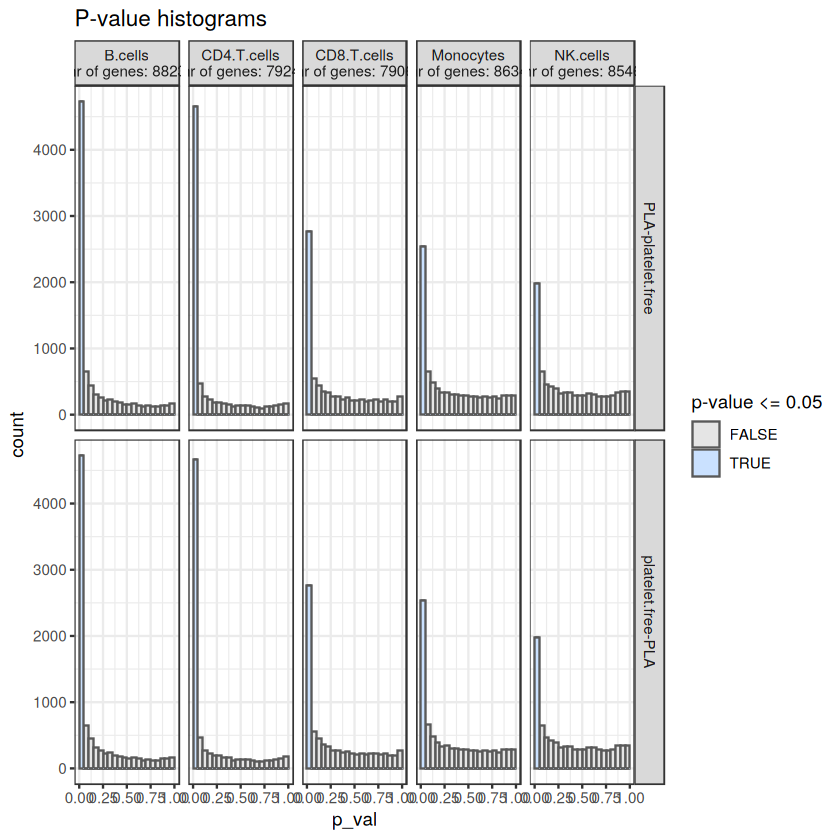

In [38]:
DE_info$hist_pvals

### Combine DE information for ligand-senders and receptors-receivers

- combine the DE information of senders and receivers by linking their ligands and receptors together based on the prior knowledge ligand-receptor network

In [39]:
celltype_de = DE_info$celltype_de$de_output_tidy

In [40]:
sender_receiver_de = combine_sender_receiver_de(
  sender_de = celltype_de,
  receiver_de = celltype_de,
  senders_oi = senders_oi,
  receivers_oi = receivers_oi,
  lr_network = lr_network
)

In [41]:
sender_receiver_de %>% head(20)

contrast,sender,receiver,ligand,receptor,lfc_ligand,lfc_receptor,ligand_receptor_lfc_avg,p_val_ligand,p_adj_ligand,p_val_receptor,p_adj_receptor
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
PLA-platelet.free,B.cells,B.cells,S100A9,CD36,5.60,4.82,5.210,3.03e-25,1.78e-22,3.11e-22,6.66e-20
PLA-platelet.free,B.cells,B.cells,S100A8,CD36,5.57,4.82,5.195,7.65e-25,3.75e-22,3.11e-22,6.66e-20
PLA-platelet.free,B.cells,B.cells,S100A12,CD36,5.53,4.82,5.175,6.13e-26,6.77e-23,3.11e-22,6.66e-20
PLA-platelet.free,B.cells,CD4.T.cells,S100A9,CD36,5.60,4.54,5.070,3.03e-25,1.78e-22,5.48e-22,1.36e-19
PLA-platelet.free,B.cells,B.cells,THBS1,ITGB3,4.76,5.37,5.065,9.03e-16,3.54e-14,1.56e-17,8.07e-16
PLA-platelet.free,B.cells,CD4.T.cells,S100A8,CD36,5.57,4.54,5.055,7.65e-25,3.75e-22,5.48e-22,1.36e-19
PLA-platelet.free,B.cells,CD4.T.cells,S100A12,CD36,5.53,4.54,5.035,6.13e-26,6.77e-23,5.48e-22,1.36e-19
PLA-platelet.free,B.cells,B.cells,THBS1,ITGA2B,4.76,5.30,5.030,9.03e-16,3.54e-14,1.53e-18,9.95e-17
PLA-platelet.free,B.cells,CD4.T.cells,THBS1,ITGA2B,4.76,5.28,5.020,9.03e-16,3.54e-14,3.24e-28,6.42e-25


1. S100A9 → CD36 is a known ligand-receptor pair in the LR prior network

2. S100A9 is differentially expressed in B cells, here as the sender ligand
   - lfc_ligand = 5.60: S100A9 expression in B cells is 2^5.60 times higher in PLA than in platelet.free

3. CD36 is differentially expressed in B cells, here as the receiver receptor

4. the average ligand/receptor logFC is positive
   so both genes tend to be higher in the numerator condition of the contrast

important things to consider:
- the DE is gene-level DE, not direct DE of the ligand-receptor interaction itself
- this is a plausible / prioritized candidate interaction, does not necessarily guarantee that just because these genes are DE in these cell types (individually) that there will be such an interaction. but plausible.

=> S100A9 → CD36 is a known LR pair, and both genes show condition-associated expression changes in the relevant sender/receiver cell types.
This supports a candidate B cell → B cell communication event.

=> NOT S100A9-CD36 communication occurs between B cells

=> but: S100A9-CD36 was prioritized as a candidate B cell–B cell interaction because the ligand S100A9 was differentially expressed in B cells, the receptor CD36 was differentially expressed in B cells, and this ligand-receptor pair is present in the prior LR network.

## Ligand activity prediction

- predict NicheNet ligand activities & NicheNet ligand-target links based on these differential expression results
- we do this to prioritize interactions based on their predicted effect on a receiver cell type
- assumption: most important group-specific interactions are those that lead to group-specific gene expression changes in a receiver cell type


- create a geneset of interest based on DE output
- assess enrichment of target genes of ligands within this geneset of interest
- high-prob target genes enriched in ligand -> ligand may have high activity

- genesets_Oi/background should be of ratio 1/200 and 1/10
- we need to define logFC and/or p-value thresholds per cell type/contrast combination
- approach: inspect nr of DE fenes for all cell types based on default thresholds & adapt accordingly
- if the smallest group >= 20 samples, we typically recommend using p_val_adj = TRUE

In [42]:
unique(celltype_de$contrast)

[1] "PLA-platelet.free" "platelet.free-PLA"

In [43]:
contrast_tbl <- tibble(
  contrast = c("PLA-platelet.free", "platelet.free-PLA"),
  group = c("PLA", "platelet.free")
)

In [44]:
logFC_threshold = 0.50
p_val_threshold = 0.05
p_val_adj = TRUE

In [45]:
geneset_assessment = contrast_tbl$contrast %>% 
  lapply(
    process_geneset_data, 
    celltype_de, logFC_threshold, p_val_adj, p_val_threshold
  ) %>% 
  bind_rows() 
geneset_assessment

Joining with `by = join_by(cluster_id)`
Joining with `by = join_by(cluster_id)`
Joining with `by = join_by(cluster_id)`
Joining with `by = join_by(cluster_id)`


cluster_id,n_background,n_geneset_up,n_geneset_down,prop_geneset_up,prop_geneset_down,in_range_up,in_range_down,contrast,logFC_threshold,p_val_threshold,adjusted
<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<lgl>,<lgl>,<chr>,<dbl>,<dbl>,<lgl>
B.cells,8823,1148,2352,0.13011447,0.26657599,FALSE,FALSE,PLA-platelet.free,0.5,0.05,TRUE
CD4.T.cells,7924,661,351,0.08341747,0.04429581,TRUE,TRUE,PLA-platelet.free,0.5,0.05,TRUE
CD8.T.cells,7906,81,80,0.01024538,0.01011890,TRUE,TRUE,PLA-platelet.free,0.5,0.05,TRUE
Monocytes,8634,162,110,0.01876303,0.01274033,TRUE,TRUE,PLA-platelet.free,0.5,0.05,TRUE
NK.cells,8546,168,179,0.01965832,0.02094547,TRUE,TRUE,PLA-platelet.free,0.5,0.05,TRUE
B.cells,8823,2352,1148,0.26657599,0.13011447,FALSE,FALSE,platelet.free-PLA,0.5,0.05,TRUE
CD4.T.cells,7924,351,661,0.04429581,0.08341747,TRUE,TRUE,platelet.free-PLA,0.5,0.05,TRUE
CD8.T.cells,7906,80,81,0.01011890,0.01024538,TRUE,TRUE,platelet.free-PLA,0.5,0.05,TRUE
Monocytes,8634,110,162,0.01274033,0.01876303,TRUE,TRUE,platelet.free-PLA,0.5,0.05,TRUE


Gene set for B cells too large, especially downregulated set

### Ligand activitiy analysis and ligand-target inference

In [46]:
top_n_target = 250 # top 250 targets per ligand

In [47]:
ligand_activities_targets_DEgenes = suppressMessages(suppressWarnings(
  get_ligand_activities_targets_DEgenes(
    receiver_de = celltype_de,
    receivers_oi = intersect(receivers_oi, celltype_de$cluster_id %>% unique()),
    ligand_target_matrix = ligand_target_matrix,
    logFC_threshold = logFC_threshold,
    p_val_threshold = p_val_threshold,
    p_val_adj = p_val_adj,
    top_n_target = top_n_target,
  )
))

In [48]:
ligand_activities_targets_DEgenes$ligand_activities %>% head(20)

ligand,activity,contrast,target,ligand_target_weight,receiver,direction_regulation,activity_scaled
<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<fct>,<dbl>
A2M,0.07499607,PLA-platelet.free,ADM,0.008285722,B.cells,up,0.7443045
A2M,0.07499607,PLA-platelet.free,AHNAK,0.007263218,B.cells,up,0.7443045
A2M,0.07499607,PLA-platelet.free,AHR,0.007609189,B.cells,up,0.7443045
A2M,0.07499607,PLA-platelet.free,ANXA1,0.006551967,B.cells,up,0.7443045
A2M,0.07499607,PLA-platelet.free,APP,0.011178972,B.cells,up,0.7443045
A2M,0.07499607,PLA-platelet.free,BCL2L1,0.011212277,B.cells,up,0.7443045
A2M,0.07499607,PLA-platelet.free,CASP1,0.006526797,B.cells,up,0.7443045
A2M,0.07499607,PLA-platelet.free,CCL5,0.008876654,B.cells,up,0.7443045
A2M,0.07499607,PLA-platelet.free,CD36,0.007029202,B.cells,up,0.7443045


In B cells, A2M is predicted to regulate target genes that are enriched among the PLA-up DE genes.
ADM is one of the predicted target genes linked to A2M.

Ligand activity = area under precision-recall curve (AUPR)

## Prioritization: rank cell-cell communication patterns through multi-criteria prioritization

we calculated:
- expression
- differential expression
- NicheNet ligand activity

prioritize based on:
- upregulation of ligand in a sender cell type and/or upregulation of receptor in receiver cell type in condition of interest
- cell-type specific expression of ligand in sender cell type, receptor in receiver cell type in condition of interest (to mitigate influence of upregulated but still relatively weakly expressed ligands/receptors)
- sufficiently high expression levels of ligand and receptor in many samples of the same group
- high nichenet ligand activity to further prioritize ligand-receptor pairs based on their predicted effect of ligand-receptor interaction on gene expression in receiver cell type

=> combine these prioritization criteria in a single aggregated prioritization score
- all criteria are weighed equally (can be changed)

we need to make one choice: prioritize ligands that only induce upregulation of target genes or can lead to both up- & downregulation
- benefit of only looking at upregulation: ease of interpretability

In [49]:
ligand_activity_down = FALSE

In [50]:
sender_receiver_tbl = sender_receiver_de %>% distinct(sender, receiver)

metadata_combined = SummarizedExperiment::colData(sce) %>% tibble::as_tibble()

if(!is.na(batches)){
  grouping_tbl = metadata_combined[,c(sample_id, group_id, batches)] %>% 
    tibble::as_tibble() %>% distinct()
  colnames(grouping_tbl) = c("sample","group",batches)
} else {
  grouping_tbl = metadata_combined[,c(sample_id, group_id)] %>% 
    tibble::as_tibble() %>% distinct()
  colnames(grouping_tbl) = c("sample","group")
}

prioritization_tables = suppressMessages(generate_prioritization_tables(
    sender_receiver_info = abundance_expression_info$sender_receiver_info,
    sender_receiver_de = sender_receiver_de,
    ligand_activities_targets_DEgenes = ligand_activities_targets_DEgenes,
    contrast_tbl = contrast_tbl,
    sender_receiver_tbl = sender_receiver_tbl,
    grouping_tbl = grouping_tbl,
    scenario = "regular", # all prioritization criteria will be weighted equally
    fraction_cutoff = fraction_cutoff, 
    abundance_data_receiver = abundance_expression_info$abundance_data_receiver,
    abundance_data_sender = abundance_expression_info$abundance_data_sender,
    ligand_activity_down = ligand_activity_down
  ))

In [51]:
prioritization_tables$group_prioritization_tbl %>% head(20)

contrast,group,sender,receiver,ligand,receptor,lr_interaction,id,scaled_lfc_ligand,scaled_p_val_ligand_adapted,scaled_lfc_receptor,scaled_p_val_receptor_adapted,max_scaled_activity,scaled_pb_ligand,scaled_pb_receptor,fraction_expressing_ligand_receptor,prioritization_score,top_group
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
platelet.free-PLA,platelet.free,B.cells,B.cells,LY86,CD180,LY86_CD180,LY86_CD180_B.cells_B.cells,0.8694444,0.8277778,0.9309912,0.8933501,1.0010000,1.0010000,1.0010000,1.000,0.9606303,platelet.free
platelet.free-PLA,platelet.free,CD4.T.cells,B.cells,CD40LG,CD40,CD40LG_CD40,CD40LG_CD40_CD4.T.cells_B.cells,0.8200000,0.8750000,0.9523212,0.9404015,0.9178385,1.0010000,1.0010000,1.000,0.9522833,platelet.free
platelet.free-PLA,platelet.free,B.cells,B.cells,HLA.DMB,CD74,HLA.DMB_CD74,HLA.DMB_CD74_B.cells_B.cells,0.9188889,0.9266667,0.9451066,0.9629862,0.8155605,1.0010000,1.0010000,1.000,0.9490641,platelet.free
platelet.free-PLA,platelet.free,B.cells,B.cells,HLA.DMA,CD74,HLA.DMA_CD74,HLA.DMA_CD74_B.cells_B.cells,0.9225000,0.9211111,0.9451066,0.9629862,0.8039563,1.0010000,1.0010000,1.000,0.9469680,platelet.free
platelet.free-PLA,platelet.free,B.cells,CD4.T.cells,IL7,IL7R,IL7_IL7R,IL7_IL7R_B.cells_CD4.T.cells,0.9538889,0.8455556,0.9008783,0.9667503,1.0010000,1.0010000,1.0010000,0.800,0.9394228,platelet.free
platelet.free-PLA,platelet.free,B.cells,B.cells,FCER2,CR2,FCER2_CR2,FCER2_CR2_B.cells_B.cells,0.9411111,0.8827778,0.9507528,0.8713927,0.7622387,1.0010000,1.0010000,1.000,0.9312093,platelet.free
PLA-platelet.free,PLA,Monocytes,Monocytes,HP,ASGR2,HP_ASGR2,HP_ASGR2_Monocytes_Monocytes,0.9033333,0.9411111,0.8290464,0.8892723,0.8266503,1.0010000,1.0010000,0.925,0.9225053,PLA
platelet.free-PLA,platelet.free,CD4.T.cells,B.cells,IFITM1,CD81,IFITM1_CD81,IFITM1_CD81_CD4.T.cells_B.cells,0.8363889,0.9333333,0.9247177,0.9335006,0.7730736,0.9960264,0.9244405,1.000,0.9179185,platelet.free
PLA-platelet.free,PLA,B.cells,CD4.T.cells,PF4,CXCR3,PF4_CXCR3,PF4_CXCR3_B.cells_CD4.T.cells,0.9991667,0.9877778,0.8651192,0.9077792,0.9110779,1.0010000,0.8844740,0.825,0.9169122,PLA


# 4. Across sample correlation

In [56]:
lr_target_prior_cor = lr_target_prior_cor_inference(
  receivers_oi = prioritization_tables$group_prioritization_tbl$receiver %>% unique(), 
  abundance_expression_info = abundance_expression_info, 
  celltype_de = celltype_de, 
  grouping_tbl = grouping_tbl, 
  prioritization_tables = prioritization_tables, 
  ligand_target_matrix = ligand_target_matrix, 
  logFC_threshold = logFC_threshold, 
  p_val_threshold = p_val_threshold, 
  p_val_adj = p_val_adj
  )

# 5. Save outputs

In [57]:
multinichenet_output = list(
    celltype_info = abundance_expression_info$celltype_info,
    celltype_de = celltype_de,
    sender_receiver_info = abundance_expression_info$sender_receiver_info,
    sender_receiver_de =  sender_receiver_de,
    ligand_activities_targets_DEgenes = ligand_activities_targets_DEgenes,
    prioritization_tables = prioritization_tables,
    grouping_tbl = grouping_tbl,
    lr_target_prior_cor = lr_target_prior_cor
  ) 
multinichenet_output = make_lite_output(multinichenet_output)

save = FALSE
if(save == TRUE){
  saveRDS(multinichenet_output, paste0(out_dir, "multinichenet_output.rds"))

}

# 6. Plots

## ChordDiagram

Joining with `by = join_by(id, sender, receiver, ligand, receptor, group)`
Joining with `by = join_by(sender)`
Joining with `by = join_by(receiver)`
Joining with `by = join_by(sender)`
Joining with `by = join_by(receiver)`


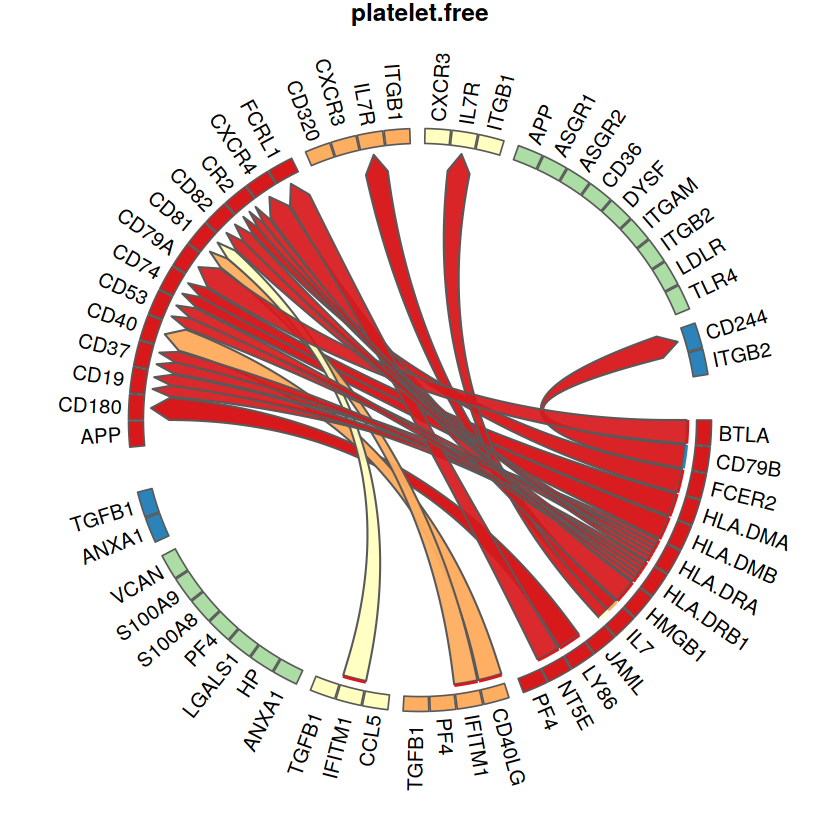

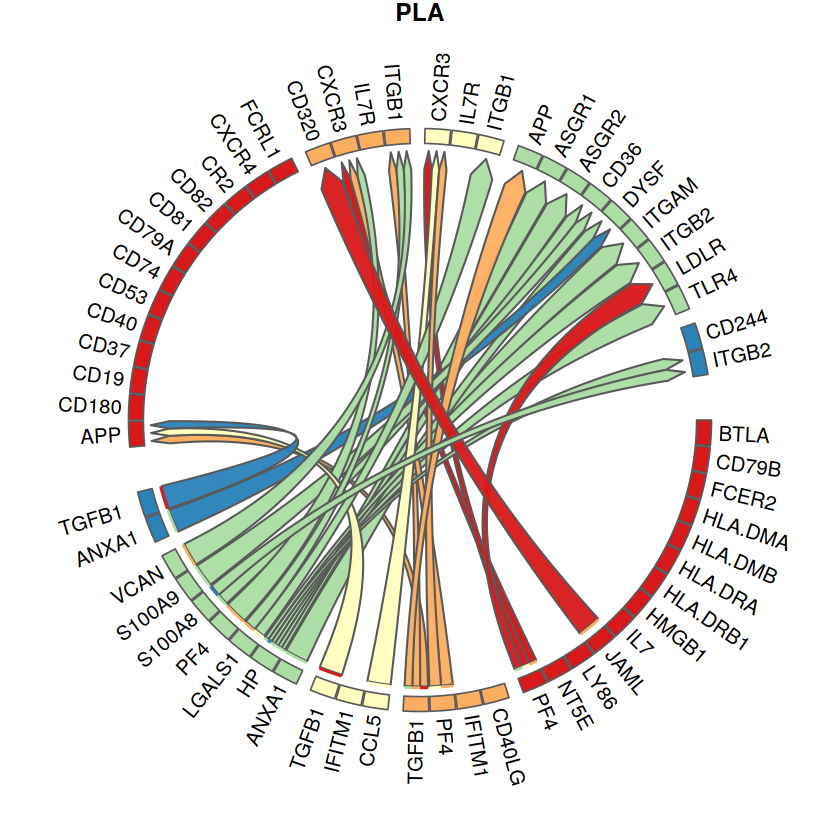

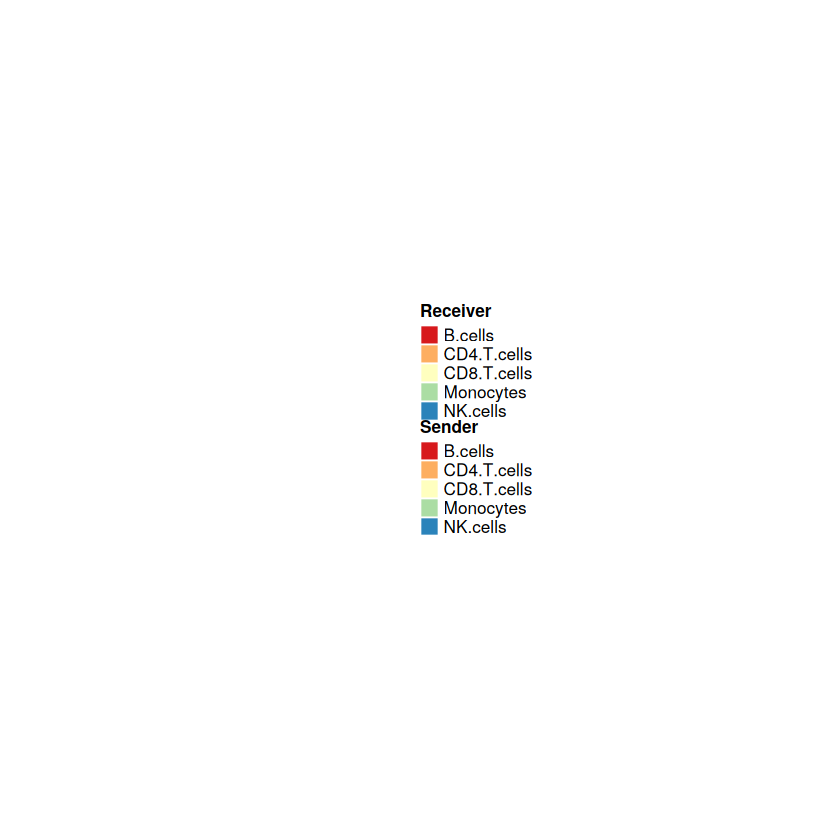

In [58]:
prioritized_tbl_oi_all = get_top_n_lr_pairs(
  multinichenet_output$prioritization_tables, 
  top_n = 50, 
  rank_per_group = FALSE
  )

prioritized_tbl_oi = 
  multinichenet_output$prioritization_tables$group_prioritization_tbl %>%
  filter(id %in% prioritized_tbl_oi_all$id) %>%
  distinct(id, sender, receiver, ligand, receptor, group) %>% 
  left_join(prioritized_tbl_oi_all)
prioritized_tbl_oi$prioritization_score[is.na(prioritized_tbl_oi$prioritization_score)] = 0

senders_receivers = union(prioritized_tbl_oi$sender %>% unique(), prioritized_tbl_oi$receiver %>% unique()) %>% sort()

colors_sender = RColorBrewer::brewer.pal(n = length(senders_receivers), name = 'Spectral') %>% magrittr::set_names(senders_receivers)
colors_receiver = RColorBrewer::brewer.pal(n = length(senders_receivers), name = 'Spectral') %>% magrittr::set_names(senders_receivers)

circos_list = make_circos_group_comparison(prioritized_tbl_oi, colors_sender, colors_receiver)

## Bubble plots

In [59]:
group_oi = "PLA"

In [60]:
prioritized_tbl_oi_PLA_50 = get_top_n_lr_pairs(
  multinichenet_output$prioritization_tables, 
  top_n = 50, 
  groups_oi = group_oi)

Joining with `by = join_by(id, sender, receiver, sender_receiver,
lr_interaction, group)`
Joining with `by = join_by(id, sender, receiver, sender_receiver,
lr_interaction, group)`
Joining with `by = join_by(receiver, sender_receiver, lr_interaction, group,
LR)`


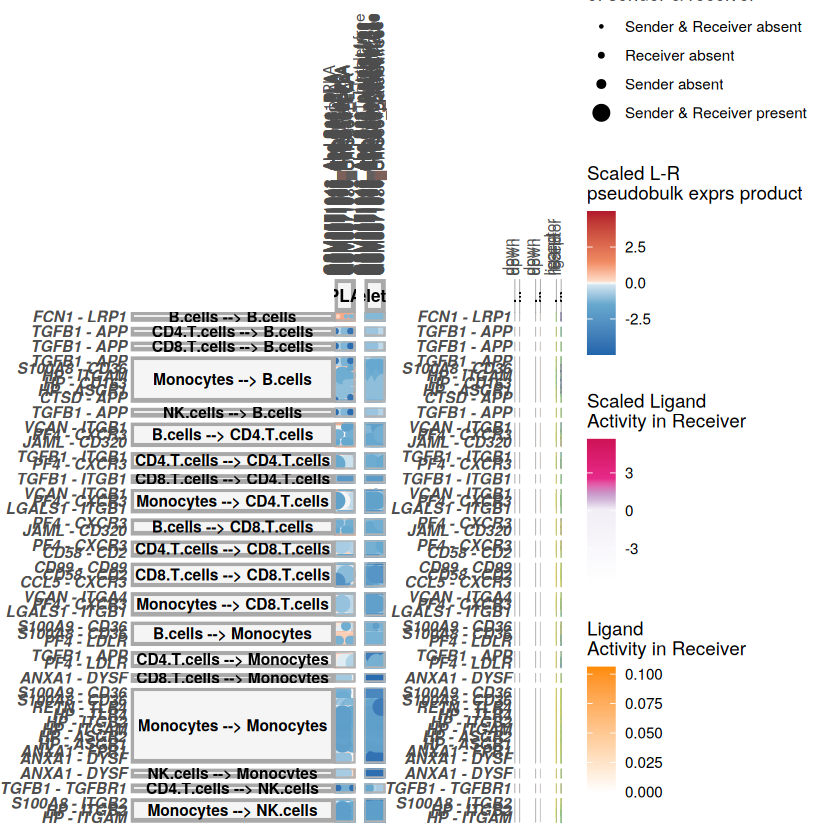

In [61]:
plot_oi = make_sample_lr_prod_activity_plots(
  multinichenet_output$prioritization_tables, 
  prioritized_tbl_oi_PLA_50)
plot_oi

- Samples that were left out of the DE analysis are indicated with a smaller dot
- level of curation of these LR pairs as defined by the Intercellular Communication part of the Omnipath database

In [62]:
mn_prio_plot <- prioritization_tables$group_prioritization_tbl %>%
  mutate(
    lineage_pair = paste(sender, receiver, sep = " → "),
    interaction = paste(ligand, receptor, sep = " → "),
    
    direction = case_when(
      group == "PLA" ~ "PLA-up",
      group == "platelet.free" ~ "platelet-free-up",
      TRUE ~ as.character(group)
    ),
    
    lfc_score = (scaled_lfc_ligand + scaled_lfc_receptor) / 2,
    expression_score = (scaled_pb_ligand + scaled_pb_receptor) / 2,
    activity_score = max_scaled_activity,
    score = prioritization_score
  )

### 1. Global distribution

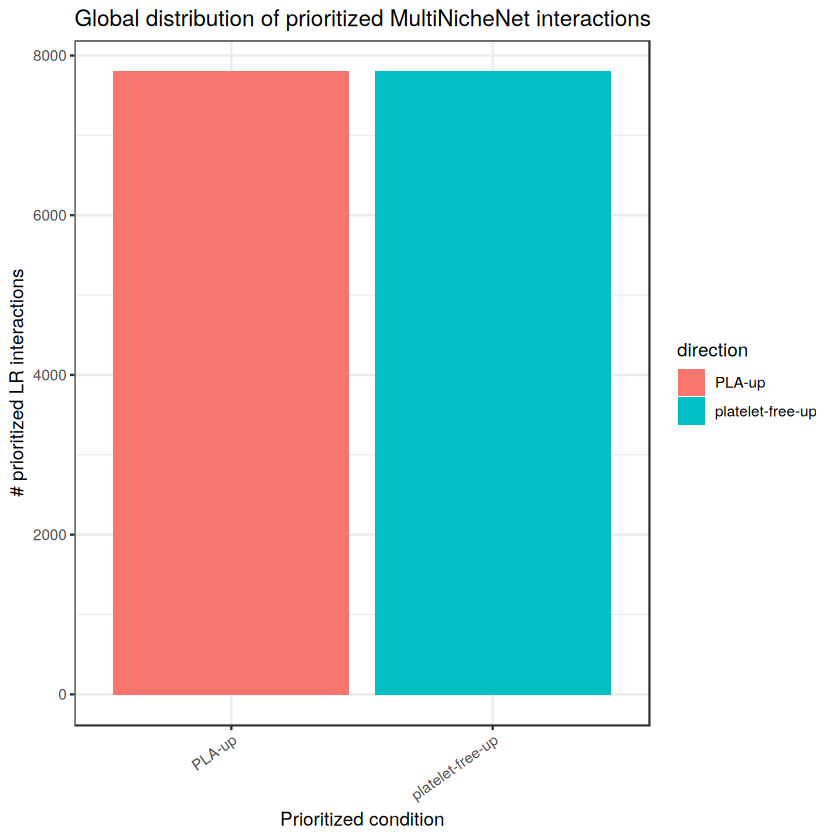

In [63]:
ggplot(mn_prio_plot, aes(x = direction, fill = direction)) +
  geom_bar() +
  theme_bw() +
  scale_fill_manual(
    values = c(
      "PLA-up" = "#F8766D",
      "platelet-free-up" = "#00BFC4"
    )
  ) +
  labs(
    title = "Global distribution of prioritized MultiNicheNet interactions",
    x = "Prioritized condition",
    y = "# prioritized LR interactions"
  ) +
  theme(axis.text.x = element_text(angle = 35, hjust = 1))

### 2. Top prioritized lineage pairs

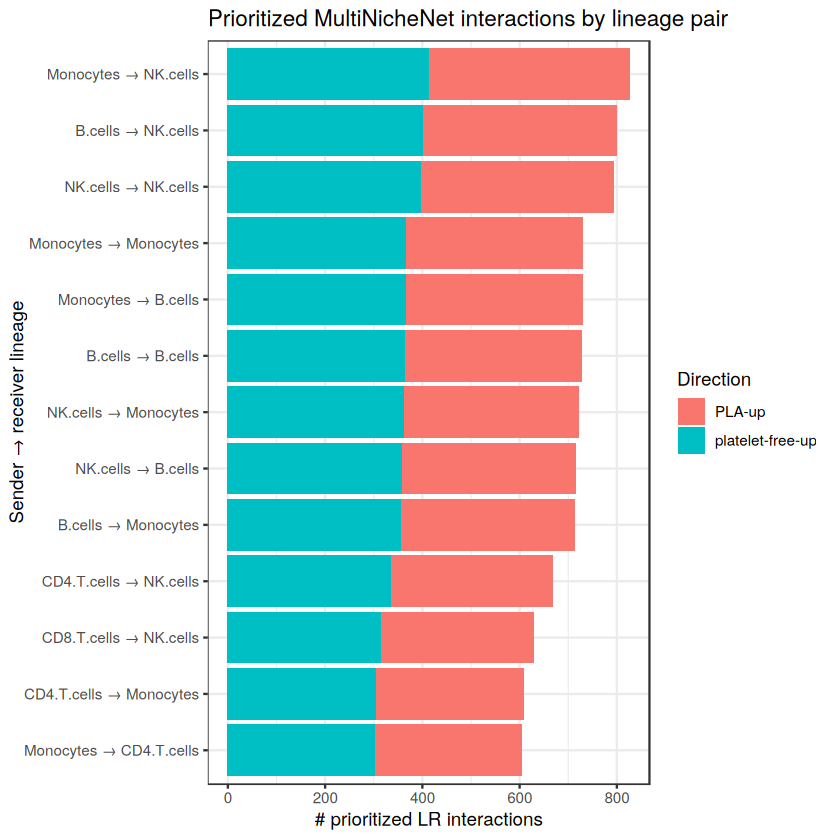

In [64]:
pair_counts_mn_prio <- mn_prio_plot %>%
  dplyr::count(lineage_pair, direction) %>%
  group_by(lineage_pair) %>%
  mutate(total = sum(n)) %>%
  ungroup() %>%
  slice_max(total, n = 25) %>%
  mutate(lineage_pair = fct_reorder(lineage_pair, total))

ggplot(pair_counts_mn_prio, aes(x = n, y = lineage_pair, fill = direction)) +
  geom_col() +
  theme_bw() +
  scale_fill_manual(
    values = c(
      "PLA-up" = "#F8766D",
      "platelet-free-up" = "#00BFC4"
    )
  ) +
  labs(
    title = "Prioritized MultiNicheNet interactions by lineage pair",
    x = "# prioritized LR interactions",
    y = "Sender → receiver lineage",
    fill = "Direction"
  )

### 3. Net direction heatmap

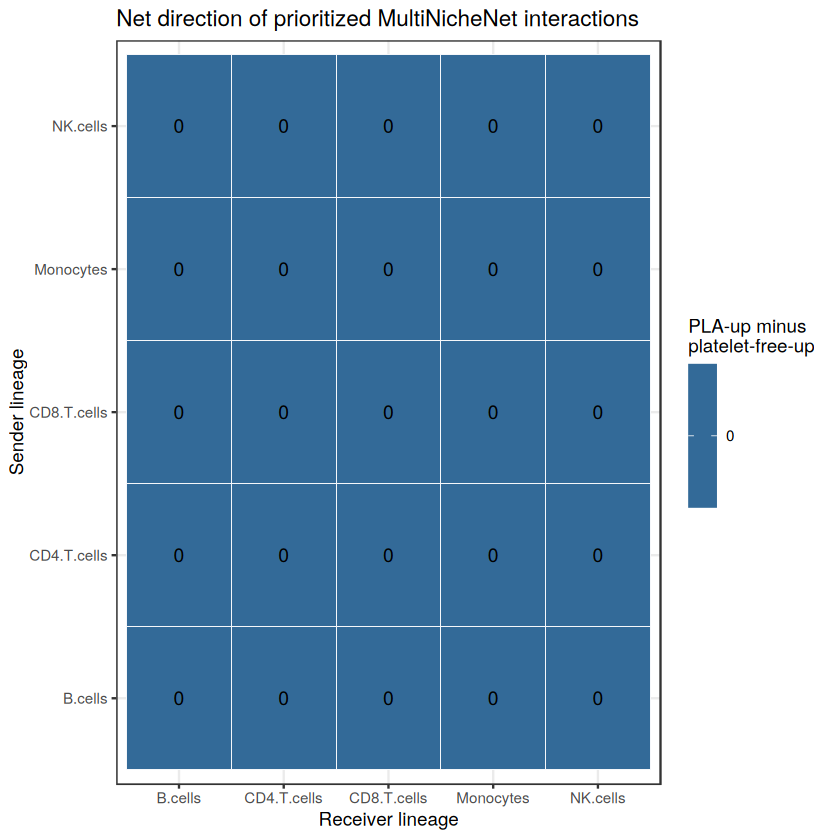

In [65]:
net_direction_mn_prio <- mn_prio_plot %>%
  dplyr::count(sender, receiver, direction) %>%
  complete(
    sender,
    receiver,
    direction = c("PLA-up", "platelet-free-up"),
    fill = list(n = 0)
  ) %>%
  pivot_wider(
    names_from = direction,
    values_from = n,
    values_fill = 0
  ) %>%
  mutate(
    net = `PLA-up` - `platelet-free-up`
  )

ggplot(net_direction_mn_prio, aes(x = receiver, y = sender, fill = net)) +
  geom_tile(color = "white") +
  geom_text(aes(label = net), size = 4) +
  theme_bw() +
  labs(
    title = "Net direction of prioritized MultiNicheNet interactions",
    x = "Receiver lineage",
    y = "Sender lineage",
    fill = "PLA-up minus\nplatelet-free-up"
  )

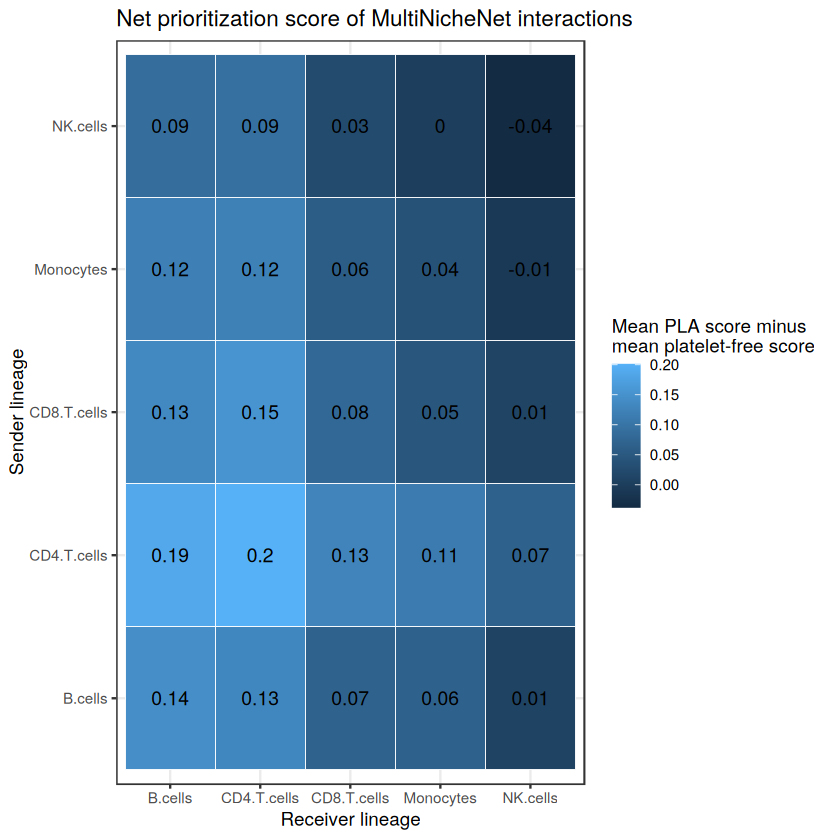

In [66]:
net_score_mn_prio <- mn_prio_plot %>%
  dplyr::group_by(sender, receiver, direction) %>%
  dplyr::summarise(
    mean_score = mean(prioritization_score, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  tidyr::complete(
    sender,
    receiver,
    direction = c("PLA-up", "platelet-free-up"),
    fill = list(mean_score = 0)
  ) %>%
  tidyr::pivot_wider(
    names_from = direction,
    values_from = mean_score,
    values_fill = 0
  )

if (!"PLA-up" %in% colnames(net_score_mn_prio)) {
  net_score_mn_prio$`PLA-up` <- 0
}

if (!"platelet-free-up" %in% colnames(net_score_mn_prio)) {
  net_score_mn_prio$`platelet-free-up` <- 0
}

net_score_mn_prio <- net_score_mn_prio %>%
  dplyr::mutate(
    net_score = `PLA-up` - `platelet-free-up`
  )

ggplot2::ggplot(
  net_score_mn_prio,
  ggplot2::aes(x = receiver, y = sender, fill = net_score)
) +
  ggplot2::geom_tile(color = "white") +
  ggplot2::geom_text(ggplot2::aes(label = round(net_score, 2)), size = 4) +
  ggplot2::theme_bw() +
  ggplot2::labs(
    title = "Net prioritization score of MultiNicheNet interactions",
    x = "Receiver lineage",
    y = "Sender lineage",
    fill = "Mean PLA score minus\nmean platelet-free score"
  )

### 4. Most recurrent prioritized LR pairs

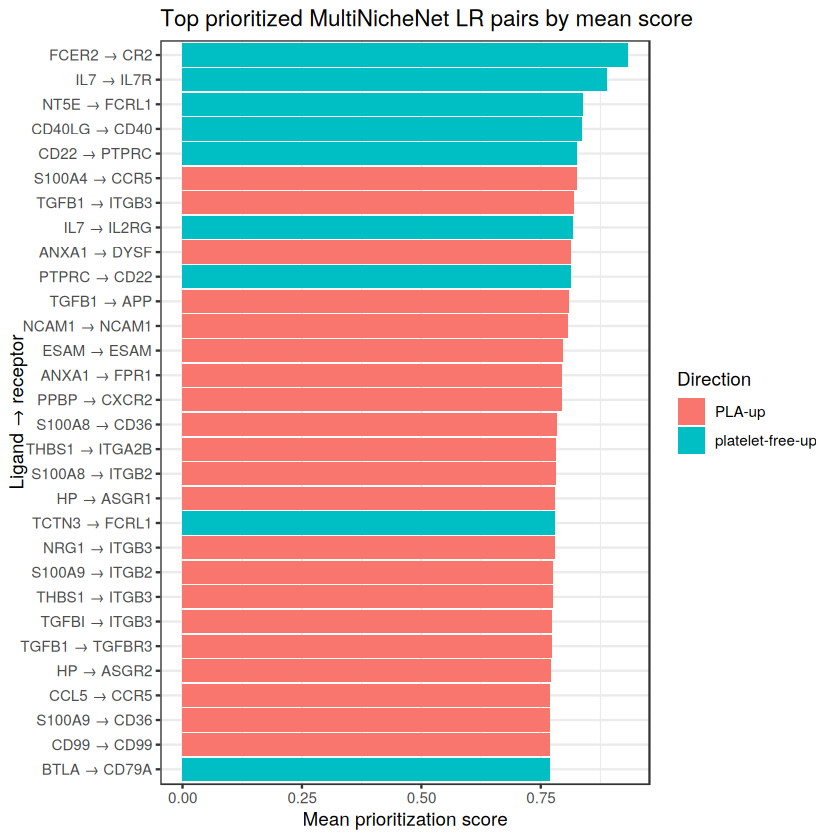

In [67]:
top_lr_by_score <- mn_prio_plot %>%
  dplyr::group_by(interaction, direction) %>%
  dplyr::summarise(
    n_lineage_pairs = dplyr::n_distinct(lineage_pair),
    mean_score = mean(prioritization_score, na.rm = TRUE),
    max_score = max(prioritization_score, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  dplyr::arrange(dplyr::desc(mean_score)) %>%
  dplyr::slice_head(n = 30) %>%
  dplyr::mutate(
    interaction = forcats::fct_reorder(interaction, mean_score)
  )

ggplot2::ggplot(
  top_lr_by_score,
  ggplot2::aes(x = mean_score, y = interaction, fill = direction)
) +
  ggplot2::geom_col() +
  ggplot2::theme_bw() +
  ggplot2::scale_fill_manual(
    values = c(
      "PLA-up" = "#F8766D",
      "platelet-free-up" = "#00BFC4"
    )
  ) +
  ggplot2::labs(
    title = "Top prioritized MultiNicheNet LR pairs by mean score",
    x = "Mean prioritization score",
    y = "Ligand → receptor",
    fill = "Direction"
  )

### 5. Top interactions per lineage pair

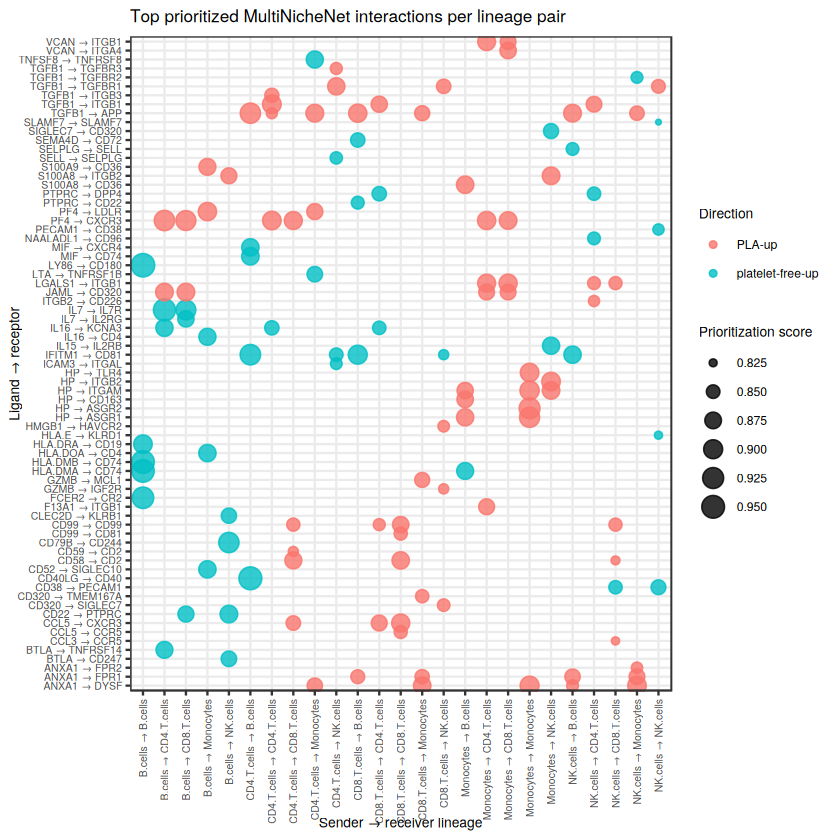

In [ ]:
top_mn_prio_per_pair <- mn_prio_plot %>%
  group_by(lineage_pair) %>%
  slice_max(prioritization_score, n = 5, with_ties = FALSE) %>%
  ungroup()

ggplot(
  top_mn_prio_per_pair,
  aes(
    x = lineage_pair,
    y = interaction,
    size = prioritization_score,
    color = direction
  )
) +
  geom_point(alpha = 0.8) +
  theme_bw() +
  scale_color_manual(
    values = c(
      "PLA-up" = "#F8766D",
      "platelet-free-up" = "#00BFC4"
    )
  ) +
  labs(
    title = "Top prioritized MultiNicheNet interactions per lineage pair",
    x = "Sender → receiver lineage",
    y = "Ligand → receptor",
    size = "Prioritization score",
    color = "Direction"
  ) +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 6),
    axis.text.y = element_text(size = 6),
    axis.title.x = element_text(size = 8),
    axis.title.y = element_text(size = 8),
    plot.title = element_text(size = 10),
    legend.title = element_text(size = 8),
    legend.text = element_text(size = 7)
  )

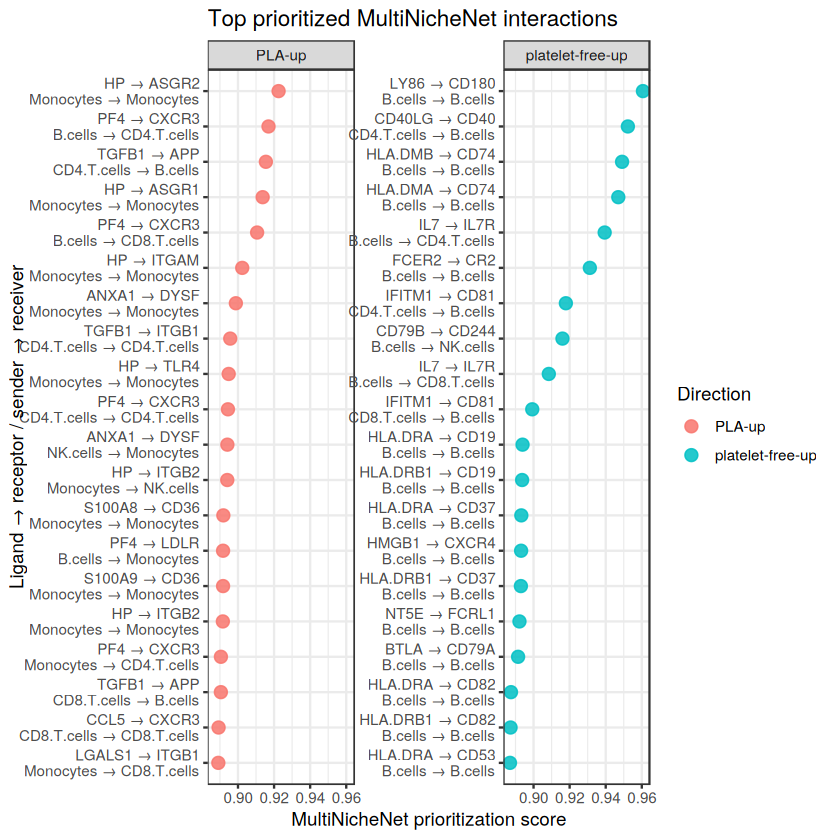

In [68]:
p_top_prioritized <- mn_prio_plot %>%
  filter(direction %in% c("PLA-up", "platelet-free-up")) %>%
  group_by(direction) %>%
  slice_max(order_by = prioritization_score, n = 20, with_ties = FALSE) %>%
  ungroup() %>%
  mutate(
    label = paste0(interaction, "\n", lineage_pair),
    label = forcats::fct_reorder(label, prioritization_score)
  ) %>%
  ggplot(aes(
    x = prioritization_score,
    y = label,
    color = direction
  )) +
  geom_point(size = 3, alpha = 0.85) +
  facet_wrap(~ direction, scales = "free_y") +
  theme_bw(base_size = 11) +
  scale_color_manual(
    values = c(
      "PLA-up" = "#F8766D",
      "platelet-free-up" = "#00BFC4"
    )
  ) +
  labs(
    x = "MultiNicheNet prioritization score",
    y = "Ligand → receptor / sender → receiver",
    color = "Direction",
    title = "Top prioritized MultiNicheNet interactions"
  )

p_top_prioritized

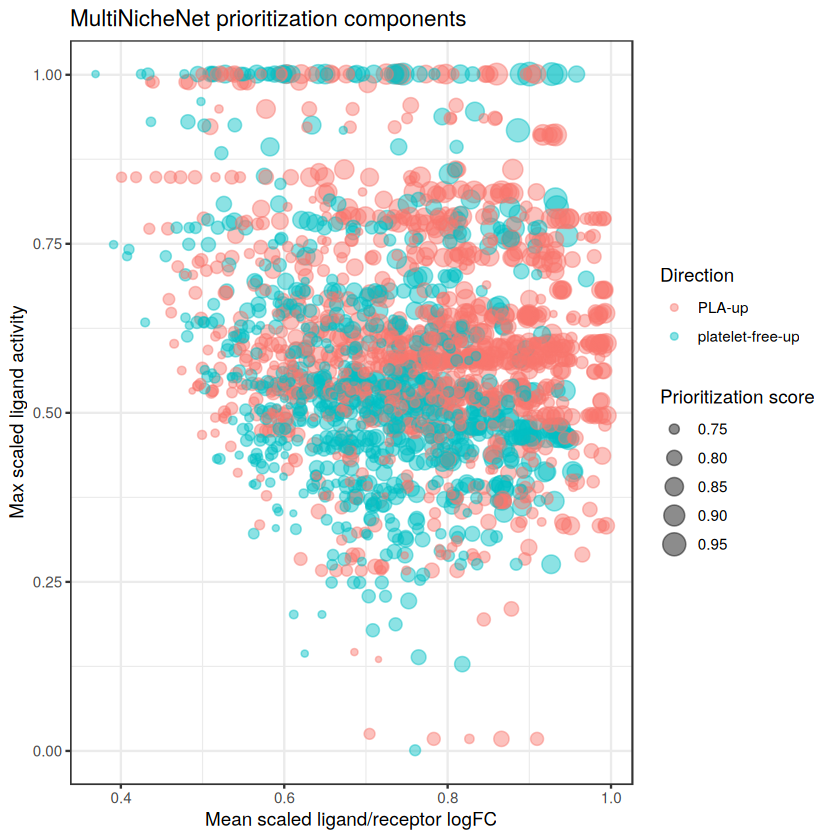

In [69]:
mn_prio_top <- mn_prio_plot %>%
  slice_max(prioritization_score, n = 2000, with_ties = FALSE)

ggplot(
  mn_prio_top,
  aes(
    x = lfc_score,
    y = activity_score,
    size = prioritization_score,
    color = direction
  )
) +
  geom_point(alpha = 0.45) +
  theme_bw() +
  scale_color_manual(
    values = c(
      "PLA-up" = "#F8766D",
      "platelet-free-up" = "#00BFC4"
    )
  ) +
  labs(
    title = "MultiNicheNet prioritization components",
    x = "Mean scaled ligand/receptor logFC",
    y = "Max scaled ligand activity",
    size = "Prioritization score",
    color = "Direction"
  )

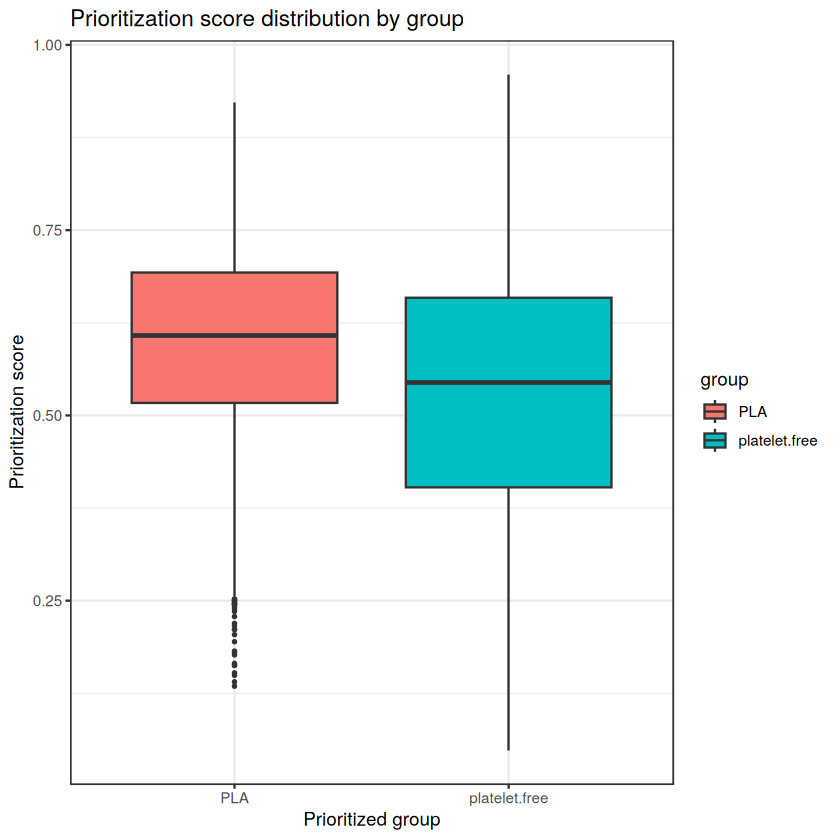

In [70]:
ggplot(
  prioritization_tables$group_prioritization_tbl,
  aes(x = group, y = prioritization_score, fill = group)
) +
  geom_boxplot(outlier.size = 0.5) +
  theme_bw() +
  labs(
    title = "Prioritization score distribution by group",
    x = "Prioritized group",
    y = "Prioritization score"
  )